In [2]:
import os
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib import font_manager as fm
import numpy as np
import seaborn as sns
from pyboat import WAnalyzer, ssg
from scipy.stats import shapiro, levene, f_oneway, kruskal
from statsmodels.stats.multicomp import pairwise_tukeyhsd
import scikit_posthocs as sp
import warnings
import itertools

In [3]:
base_path1 = r"/Users/katharinasonnen/Library/CloudStorage/OneDrive-HubrechtInstitute/data/RSPO/Axin-LGR5-ECD/LGR-ECD/LGR5-ECD-oscillations.xlsx"

#import data
df = pd.read_excel(base_path1)
display(df)



,time,Position,Axin2 Intensity,Condition,Experiment,Axin2 Intensity Raw
0,0,1,0.635819,control,1,886.20
1,10,1,0.717467,control,1,1000.00
2,20,1,0.789572,control,1,1100.50
3,30,1,0.817553,control,1,1139.50
4,40,1,0.802917,control,1,1119.10
...,...,...,...,...,...,...
5750,1060,48,1.119771,LGR-ECD,6,1684.80
5751,1070,48,1.109967,LGR-ECD,6,1670.05
5752,1080,48,1.086639,LGR-ECD,6,1634.95
5753,1090,48,1.056032,LGR-ECD,6,1588.90


In [5]:
#get phase from Hes7 plots and add new column
# --- set basic parameters and initialize the Analyzer---
dt = 10 # the sampling interval, 10 min
periods = np.linspace(50, 300, 100) # period range
wAn = WAnalyzer(periods, dt, time_unit_label='timepoint')

# --- Filtering ---

# calculate the trend with a 
T_c = 210


my_pyboat_results = pd.DataFrame()

unique_positions = df['Position'].unique()


for i in unique_positions:
    subset = df[df['Position'] == i]

    yourlistofsignals = subset["Axin2 Intensity"]

    trend = wAn.sinc_smooth(yourlistofsignals, T_c=T_c)
    detrended_signal = yourlistofsignals - trend
    modulus, transform = wAn.compute_spectrum(detrended_signal, do_plot= False)
    wAn.get_maxRidge(power_thresh = 0, smoothing_wsize=10)
    norm_signal = wAn.normalize_amplitude(detrended_signal, window_size=150) #important try

    #display(wAn.ridge_data)

    data = {
        'norm_signal': norm_signal,
        'phase': wAn.ridge_data['phase'].values,
        'instant period': wAn.ridge_data['periods'].values,
        'amplitude': wAn.ridge_data['amplitude'].values
    }

    my_pyboat_results = pd.concat([my_pyboat_results, wAn.ridge_data], ignore_index=True)

    
my_pyboat_results = pd.concat([my_pyboat_results, df['Condition'], df["Position"], df["Axin2 Intensity"], df["Axin2 Intensity Raw"], df["Experiment"]], axis=1)
    

display(my_pyboat_results)

my_pyboat_results.to_csv('/Users/katharinasonnen/Library/CloudStorage/OneDrive-HubrechtInstitute/data/RSPO/Axin-LGR5-ECD/LGR-ECD/out.csv', index=True) 


,time,periods,phase,amplitude,power,frequencies,Condition,Position,Axin2 Intensity,Axin2 Intensity Raw,Experiment
0,0,189.348026,2.875857,0.029799,1.373580,0.005281,control,1,0.635819,886.20,1
1,10,188.747616,3.210691,0.031217,1.507416,0.005298,control,1,0.717467,1000.00,1
2,20,188.247275,3.545894,0.032661,1.650158,0.005312,control,1,0.789572,1100.50,1
3,30,187.820513,3.881502,0.034129,1.801858,0.005324,control,1,0.817553,1139.50,1
4,40,187.440842,4.143962,0.035870,1.963699,0.005335,control,1,0.802917,1119.10,1
...,...,...,...,...,...,...,...,...,...,...,...
5750,1060,140.909091,6.152519,0.063787,6.987879,0.007097,LGR-ECD,48,1.119771,1684.80,6
5751,1070,140.909091,0.317083,0.060207,6.225398,0.007097,LGR-ECD,48,1.109967,1670.05,6
5752,1080,140.909091,0.765444,0.056658,5.513066,0.007097,LGR-ECD,48,1.086639,1634.95,6
5753,1090,140.909091,1.214398,0.053156,4.852650,0.007097,LGR-ECD,48,1.056032,1588.90,6


/var/folders/jz/gfj_b5gj1yx0lfb2z6dyr1200000gp/T/ipykernel_93646/647137246.py:51: FutureWarning: Use "auto" to set automatic grayscale colors. From v0.14.0, "gray" will default to matplotlib's definition.
  sns.stripplot(x='Condition', y='periods', data=plot_df,
INFO:fontTools.subset:maxp pruned
INFO:fontTools.subset:LTSH dropped
INFO:fontTools.subset:cmap pruned
INFO:fontTools.subset:kern dropped
INFO:fontTools.subset:post pruned
INFO:fontTools.subset:PCLT dropped
INFO:fontTools.subset:JSTF dropped
INFO:fontTools.subset:DSIG dropped
INFO:fontTools.subset:GPOS pruned
INFO:fontTools.subset:GSUB pruned
INFO:fontTools.subset:glyf pruned
INFO:fontTools.subset:Added gid0 to subset
INFO:fontTools.subset:Added first four glyphs to subset
INFO:fontTools.subset:Closing glyph list over 'GSUB': 34 glyphs before
INFO:fontTools.subset:Glyph names: ['.notdef', '.null', 'C', 'D', 'E', 'G', 'L', 'O', 'P', 'R', 'S', 'c', 'd', 'e', 'eight', 'four', 'hyphen', 'i', 'l', 'm', 'n', 'nonmarkingreturn', 'o', 

Normality per group: [np.True_, np.True_, np.True_]
Equal variances (Levene p=0.4049): True
Using ANOVA
ANOVA p = 0.8027


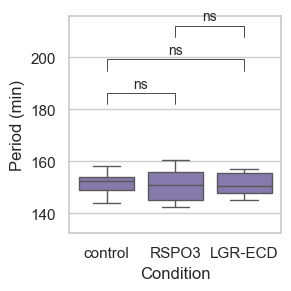

In [23]:
#Plot period

# Filter data
plot_df = my_pyboat_results[
    (my_pyboat_results['time'] > 300) &
    (my_pyboat_results['time'] < 1200) &
    (my_pyboat_results['power'] > 3)
]

# Average per sample (Position + Condition)
plot_df = plot_df.groupby(['Position', 'Condition'], as_index=False)['periods'].mean()


# --- STATISTICS ---
groups = plot_df['Condition'].unique()
group_data = [plot_df[plot_df['Condition'] == g]['periods'] for g in groups]

# Normality
normality = [shapiro(g)[1] > 0.05 for g in group_data]
print("Normality per group:", normality)

# Equal variances
levene_p = levene(*group_data)[1]
equal_var = levene_p > 0.05
print(f"Equal variances (Levene p={levene_p:.4f}): {equal_var}")

# Overall test
if all(normality) and equal_var:
    print("Using ANOVA")
    overall_p = f_oneway(*group_data)[1]
    print(f"ANOVA p = {overall_p:.4f}")
    if overall_p < 0.05:
        print("Significant: running Tukey")
        tukey = pairwise_tukeyhsd(endog=plot_df['periods'], groups=plot_df['Condition'], alpha=0.05)
        pvalues = {(a, b): tukey.pvalues[i]
                   for i, (a, b) in enumerate(itertools.combinations(tukey.groupsunique, 2))}
else:
    print("Using Kruskal-Wallis")
    overall_p = kruskal(*group_data)[1]
    print(f"Kruskal-Wallis p = {overall_p:.4f}")
    if overall_p < 0.05:
        print("Significant: running Dunn's test")
        dunn = sp.posthoc_dunn(plot_df, val_col='periods', group_col='Condition', p_adjust='bonferroni')
        pvalues = {(a, b): dunn.loc[a, b] for a, b in itertools.combinations(groups, 2)}

# --- PLOTTING ---
sns.set(style="whitegrid")
plt.figure(figsize=(3, 3))

ax = sns.boxplot(x='Condition', y='periods', data=plot_df, color='m', showfliers=False)
sns.stripplot(x='Condition', y='periods', data=plot_df,
              ax=ax, facecolor='none', linewidth=0.5, edgecolor='gray', size=4)

plt.ylabel('Period (min)', fontsize=12)

# Significance annotations
xticks = {label: idx for idx, label in enumerate(plot_df['Condition'].unique())}
y_max = plot_df['periods'].max()

def significance_label(p):
    if p < 0.001: return '***'
    elif p < 0.01: return '**'
    elif p < 0.05: return '*'
    else: return 'ns'

height_step = y_max * 0.05
height = y_max + height_step

for (g1, g2), p in pvalues.items():
    x1, x2 = xticks[g1], xticks[g2]
    y = height
    ax.plot([x1, x1, x2, x2], [y, y + height_step/2, y + height_step/2, y],
            lw=0.5, color='black')
    if overall_p < 0.05:
        label = significance_label(p)
    else:
        label = "ns"
    ax.text((x1 + x2) / 2, y + height_step * 0.6, label,
            ha='center', va='bottom', fontsize=10)
    height += height_step * 1.5


plt.rcParams.update({
    'pdf.fonttype': 42,
    'ps.fonttype': 42,
    'font.size': 12,
    'font.family': 'Arial'
})
sns.set_context('paper')

plt.tight_layout()
plt.savefig("/Users/katharinasonnen/Library/CloudStorage/OneDrive-HubrechtInstitute/data/RSPO/Axin-LGR5-ECD/LGR-ECD/boxplot_editable_period.pdf",
            format='pdf', transparent=True, dpi=600)

plt.show()


/var/folders/jz/gfj_b5gj1yx0lfb2z6dyr1200000gp/T/ipykernel_93646/1387180195.py:51: FutureWarning: Use "auto" to set automatic grayscale colors. From v0.14.0, "gray" will default to matplotlib's definition.
  sns.stripplot(x='Condition', y='amplitude', data=plot_df,
INFO:fontTools.subset:maxp pruned
INFO:fontTools.subset:LTSH dropped
INFO:fontTools.subset:cmap pruned
INFO:fontTools.subset:kern dropped
INFO:fontTools.subset:post pruned
INFO:fontTools.subset:PCLT dropped
INFO:fontTools.subset:JSTF dropped
INFO:fontTools.subset:DSIG dropped
INFO:fontTools.subset:GPOS pruned
INFO:fontTools.subset:GSUB pruned
INFO:fontTools.subset:glyf pruned
INFO:fontTools.subset:Added gid0 to subset
INFO:fontTools.subset:Added first four glyphs to subset
INFO:fontTools.subset:Closing glyph list over 'GSUB': 38 glyphs before
INFO:fontTools.subset:Glyph names: ['.notdef', '.null', 'A', 'C', 'D', 'E', 'G', 'L', 'O', 'P', 'R', 'S', 'a', 'asterisk', 'c', 'd', 'e', 'five', 'hyphen', 'i', 'l', 'm', 'n', 'nonmarki

Normality per group: [np.True_, np.True_, np.True_]
Equal variances (Levene p=0.4290): True
Using ANOVA
ANOVA p = 0.0014
Significant: running Tukey


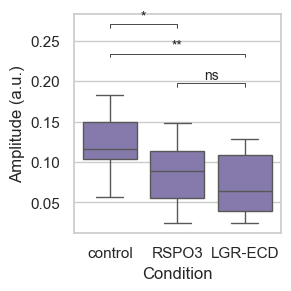

In [12]:
#Plot amplitude

# Filter data
plot_df = my_pyboat_results[
    (my_pyboat_results['time'] > 300) &
    (my_pyboat_results['time'] < 1200) &
    (my_pyboat_results['power'] > 3)
]

# Average per sample (Position + Condition)
plot_df = plot_df.groupby(['Position', 'Condition'], as_index=False)['amplitude'].mean()


# --- STATISTICS ---
groups = plot_df['Condition'].unique()
group_data = [plot_df[plot_df['Condition'] == g]['amplitude'] for g in groups]

# Normality
normality = [shapiro(g)[1] > 0.05 for g in group_data]
print("Normality per group:", normality)

# Equal variances
levene_p = levene(*group_data)[1]
equal_var = levene_p > 0.05
print(f"Equal variances (Levene p={levene_p:.4f}): {equal_var}")

# Overall test
if all(normality) and equal_var:
    print("Using ANOVA")
    overall_p = f_oneway(*group_data)[1]
    print(f"ANOVA p = {overall_p:.4f}")
    if overall_p < 0.05:
        print("Significant: running Tukey")
        tukey = pairwise_tukeyhsd(endog=plot_df['amplitude'], groups=plot_df['Condition'], alpha=0.05)
        pvalues = {(a, b): tukey.pvalues[i]
                   for i, (a, b) in enumerate(itertools.combinations(tukey.groupsunique, 2))}
else:
    print("Using Kruskal-Wallis")
    overall_p = kruskal(*group_data)[1]
    print(f"Kruskal-Wallis p = {overall_p:.4f}")
    if overall_p < 0.05:
        print("Significant: running Dunn's test")
        dunn = sp.posthoc_dunn(plot_df, val_col='amplitude', group_col='Condition', p_adjust='bonferroni')
        pvalues = {(a, b): dunn.loc[a, b] for a, b in itertools.combinations(groups, 2)}

# --- PLOTTING ---
sns.set(style="whitegrid")
plt.figure(figsize=(3, 3))

ax = sns.boxplot(x='Condition', y='amplitude', data=plot_df, color='m', showfliers=False)
sns.stripplot(x='Condition', y='amplitude', data=plot_df,
              ax=ax, facecolor='none', linewidth=0.5, edgecolor='gray', size=4)

plt.ylabel('Amplitude (a.u.)', fontsize=12)

# Significance annotations
xticks = {label: idx for idx, label in enumerate(plot_df['Condition'].unique())}
y_max = plot_df['amplitude'].max()

def significance_label(p):
    if p < 0.001: return '***'
    elif p < 0.01: return '**'
    elif p < 0.05: return '*'
    else: return 'ns'

height_step = y_max * 0.05
height = y_max + height_step

for (g1, g2), p in pvalues.items():
    x1, x2 = xticks[g1], xticks[g2]
    y = height
    ax.plot([x1, x1, x2, x2], [y, y + height_step/2, y + height_step/2, y],
            lw=0.5, color='black')
    if overall_p < 0.05:
        label = significance_label(p)
    else:
        label = "ns"
    ax.text((x1 + x2) / 2, y + height_step * 0.6, label,
            ha='center', va='bottom', fontsize=10)
    height += height_step * 4


plt.rcParams.update({
    'pdf.fonttype': 42,
    'ps.fonttype': 42,
    'font.size': 12,
    'font.family': 'Arial'
})
sns.set_context('paper')

plt.tight_layout()
plt.savefig("/Users/katharinasonnen/Library/CloudStorage/OneDrive-HubrechtInstitute/data/RSPO/Axin-LGR5-ECD/LGR-ECD/boxplot_editable_amplitude.pdf",
            format='pdf', transparent=True, dpi=600)

plt.show()

/var/folders/jz/gfj_b5gj1yx0lfb2z6dyr1200000gp/T/ipykernel_93646/2375110928.py:50: FutureWarning: Use "auto" to set automatic grayscale colors. From v0.14.0, "gray" will default to matplotlib's definition.
  sns.stripplot(x='Condition', y='Axin2 Intensity Raw', data=plot_df,
INFO:fontTools.subset:maxp pruned
INFO:fontTools.subset:LTSH dropped
INFO:fontTools.subset:cmap pruned
INFO:fontTools.subset:kern dropped
INFO:fontTools.subset:post pruned
INFO:fontTools.subset:PCLT dropped
INFO:fontTools.subset:JSTF dropped
INFO:fontTools.subset:DSIG dropped
INFO:fontTools.subset:GPOS pruned
INFO:fontTools.subset:GSUB pruned
INFO:fontTools.subset:glyf pruned
INFO:fontTools.subset:Added gid0 to subset
INFO:fontTools.subset:Added first four glyphs to subset
INFO:fontTools.subset:Closing glyph list over 'GSUB': 39 glyphs before
INFO:fontTools.subset:Glyph names: ['.notdef', '.null', 'A', 'C', 'D', 'E', 'G', 'L', 'O', 'P', 'R', 'S', 'T', 'a', 'asterisk', 'c', 'd', 'e', 'five', 'hyphen', 'i', 'l', 'n',

Normality per group: [np.False_, np.True_, np.True_]
Equal variances (Levene p=0.8578): True
Using Kruskal-Wallis
Kruskal-Wallis p = 0.0006
Significant: running Dunn's test


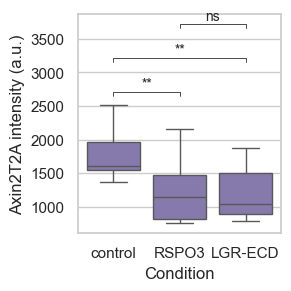

In [17]:
#Plot the intensity

# Filter data
plot_df = my_pyboat_results[
    (my_pyboat_results['time'] > 300) &
    (my_pyboat_results['time'] < 1200)
]

# Average per sample (Position + Condition)
plot_df = plot_df.groupby(['Position', 'Condition'], as_index=False)['Axin2 Intensity Raw'].mean()

# --- STATISTICS ---
groups = plot_df['Condition'].unique()
group_data = [plot_df[plot_df['Condition'] == g]['Axin2 Intensity Raw'] for g in groups]

# Normality
normality = [shapiro(g)[1] > 0.05 for g in group_data]
print("Normality per group:", normality)

# Equal variances
levene_p = levene(*group_data)[1]
equal_var = levene_p > 0.05
print(f"Equal variances (Levene p={levene_p:.4f}): {equal_var}")

# Overall test
if all(normality) and equal_var:
    print("Using ANOVA")
    overall_p = f_oneway(*group_data)[1]
    print(f"ANOVA p = {overall_p:.4f}")
    if overall_p < 0.05:
        print("Significant: running Tukey")
        tukey = pairwise_tukeyhsd(endog=plot_df['Axin2 Intensity Raw'], groups=plot_df['Condition'], alpha=0.05)
        pvalues = {(a, b): tukey.pvalues[i]
                   for i, (a, b) in enumerate(itertools.combinations(tukey.groupsunique, 2))}
else:
    print("Using Kruskal-Wallis")
    overall_p = kruskal(*group_data)[1]
    print(f"Kruskal-Wallis p = {overall_p:.4f}")
    if overall_p < 0.05:
        print("Significant: running Dunn's test")
        dunn = sp.posthoc_dunn(plot_df, val_col='Axin2 Intensity Raw', group_col='Condition', p_adjust='bonferroni')
        pvalues = {(a, b): dunn.loc[a, b] for a, b in itertools.combinations(groups, 2)}
        

# --- PLOTTING ---
sns.set(style="whitegrid")
plt.figure(figsize=(3, 3))

ax = sns.boxplot(x='Condition', y='Axin2 Intensity Raw', data=plot_df, color='m', showfliers=False)
sns.stripplot(x='Condition', y='Axin2 Intensity Raw', data=plot_df,
              ax=ax, facecolor='none', linewidth=0.5, edgecolor='gray', size=4)

plt.ylabel('Axin2T2A intensity (a.u.)', fontsize=12)

# Significance annotations
xticks = {label: idx for idx, label in enumerate(plot_df['Condition'].unique())}
y_max = plot_df['Axin2 Intensity Raw'].max()

def significance_label(p):
    if p < 0.001: return '***'
    elif p < 0.01: return '**'
    elif p < 0.05: return '*'
    else: return 'ns'

height_step = y_max * 0.05
height = y_max + height_step

for (g1, g2), p in pvalues.items():
    x1, x2 = xticks[g1], xticks[g2]
    y = height
    ax.plot([x1, x1, x2, x2], [y, y + height_step/2, y + height_step/2, y],
            lw=0.5, color='black')
    if overall_p < 0.05:
        label = significance_label(p)
    else:
        label = "ns"
    ax.text((x1 + x2) / 2, y + height_step * 0.6, label,
            ha='center', va='bottom', fontsize=10)
    height += height_step * 4


plt.rcParams.update({
    'pdf.fonttype': 42,
    'ps.fonttype': 42,
    'font.size': 12,
    'font.family': 'Arial'
})
sns.set_context('paper')

plt.tight_layout()
plt.savefig("/Users/katharinasonnen/Library/CloudStorage/OneDrive-HubrechtInstitute/data/RSPO/Axin-LGR5-ECD/LGR-ECD/boxplot_editable_intensity.pdf",
            format='pdf', transparent=True, dpi=600)

plt.show()